# 9-1. 의사결정나무와 앙상블
## 9-1-1. 의사결정나무

데이터를 분류하거나 예측하기 위한 트리(Tree) 구조의 모델이며, 조건을 담은 노드와 노드를 잇는 엣지로 구성된다.  

| 구분       | 설명                                   |
| -------- | ------------------------------------ |
| 💡 목적    | 분류(Classification) 또는 회귀(Regression) |
| 🌲 구조    | 노드와 엣지로 구성된 트리 구조                    |
| 🔀 분기 기준 | 불순도(정보이득, 지니지수 등)를 최소화하도록 선택         |
| 🧠 작동 방식 | 데이터를 조건에 따라 반복적으로 분할하여 예측 결과 도출      |


| 요소                        | 설명                           |
| ------------------------- | ---------------------------- |
| **루트 노드** (Root Node)     | 트리의 시작점 (모든 데이터를 포함)         |
| **내부 노드** (Internal Node) | 조건에 따라 데이터를 나누는 지점           |
| **단말 노드** (Leaf Node)     | 최종 예측 결과를 나타냄                |
| **분할 기준**                 | 정보이득, 지니지수 (분류) / 분산 감소 (회귀) |


- 장점: 해석이 쉽고 시각화 가능, 범주형, 수치형 변수 모두 처리 가능, 스케일링 불필요, 이상치나 결측치에 강건함
- 단점: 과적합 가능성 높음(트리크기 제한), 작은 변화에 민감함(데이터가 조금만 달라져도 구조바뀜), 일반화 성능 낮음,   
  데이터 밖의 새로운 데이터 예측 불가(시계열 데이터에 맞지 않는 모델)

<불순도 종류>
- 분류: 엔트로피, 지니불순도, log loss
- 회귀: squared error, friedman MSE, absolute error, poisson

| 불순도 지표                    | 수식 또는 정의                     | 설명                         | 특징              |
| ------------------------- | ---------------------------- | -------------------------- | --------------- |
| **지니 불순도** (Gini Impurity) | $G = 1 - \sum p_i^2$         | 각 클래스의 비율 $p_i$의 제곱을 뺀 값   | 가장 널리 쓰임 |
| **엔트로피** (Entropy)        | $H = -\sum p_i \log_2 p_i$   | 정보 이론 기반의 지표. 클래스의 혼잡도를 측정 | 지니보다 조금 더 계산 복잡 |


In [6]:
# 불순도 계산공식
from collections import Counter
import numpy as np

def entropy(data):
    if type(data[0]) == float: #클래스별 확률을 입력값으로 받는 경우
        ratio = np.array(data)
        value = -(ratio*np.log2(ratio)).sum()
    else: #범주형일 경우
        cnt = Counter(data)
        freq = np.array(list(cnt.values()))
        ratio = freq/freq.sum()
        value = -(ratio*np.log2(ratio)).sum()
    return value

def gini(data):
    if type(data[0]) == float: #클래스별 확률을 입력값으로 받는 경우
        ratio = np.array(data)
        value =1-(ratio**2).sum()
    else: #범주형일 경우
        cnt = Counter(data)
        freq = np.array(list(cnt.values()))
        ratio = freq/freq.sum()
        value =1-(ratio**2).sum()
    return value   

In [10]:
# 이진분류 데이터
r1 = ['A']*3+['B']*2
e1 = entropy(r1)
e2 = entropy([3/5, 2/5])
print(f"엔트로피: {e1:.3f} / {e2:.3f}") #0에 가까울수록 좋음(불순도니까)

g1 = gini(r1)
g2 = gini([3/5, 2/5])
print(f"지니불순도: {g1:.3f} / {g2:.3f}")

엔트로피: 0.971 / 0.971
지니불순도: 0.480 / 0.480


In [48]:
# 다중 클래스
r2 = ['A', 'B', 'C', 'C']+['D']*4

e1 = entropy(r2)
e2 = entropy([0.125, 0.125, 0.25 , 0.5])
print(f"엔트로피: {e1:.3f} / {e2:.3f}") #0에 가까울수록 좋음(불순도니까)

g1 = gini(r2)
g2 = gini([0.125, 0.125, 0.25 , 0.5])
print(f"지니불순도: {g1:.3f} / {g2:.3f}")

엔트로피: 1.750 / 1.750
지니불순도: 0.656 / 0.656


#### 특성 중요도: feature importance

트리를 만드는 결정에 각 피쳐가 얼마나 사용되었는지를 나타내는 값으로, 특성 중요도의 전체 합은 1임  
어떤 특성의 중요도가 낮더라도 이 특성이 중요하지 않은 것은 아니며, 트리분기 시 다른 피처가 동일한 정보를 가지고 있어서 해당 피처를  
사용하지 않았을 수도 있기 때문임.  

특성중요도는 항상 양수이며, 해당 피처가 종속변수의 어느 클래스를 지지하는지(분류), 양의 관계인지 음의 관계인지(회귀) 알 수 없다.  

<과적합 제어전략>  
- 사전 가지치기(pre-pruning): 트리의 최대깊이, 리프의 최대갯수, 노드가 분할할 데이터의 최소개수 지정으로 트리생성 규제
  - 하이퍼파라미터: max-depth, max_leaf_nodes, min_samples_leaf, min_samples_split
- 사후 가지치기(post-pruning): 트리를 만든 후 데이터 포인트가 적은 노드를 삭제하거나 병합

In [55]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

cancer = load_breast_cancer()
X = cancer.data
Y = cancer.target

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, stratify=Y, random_state=42)

dt = DecisionTreeClassifier(max_depth=3, criterion='gini')
dt.fit(train_X, train_Y)

pred = dt.predict(test_X)
print(f"정확도: {dt.score(test_X, test_Y):.3f}")

정확도: 0.930


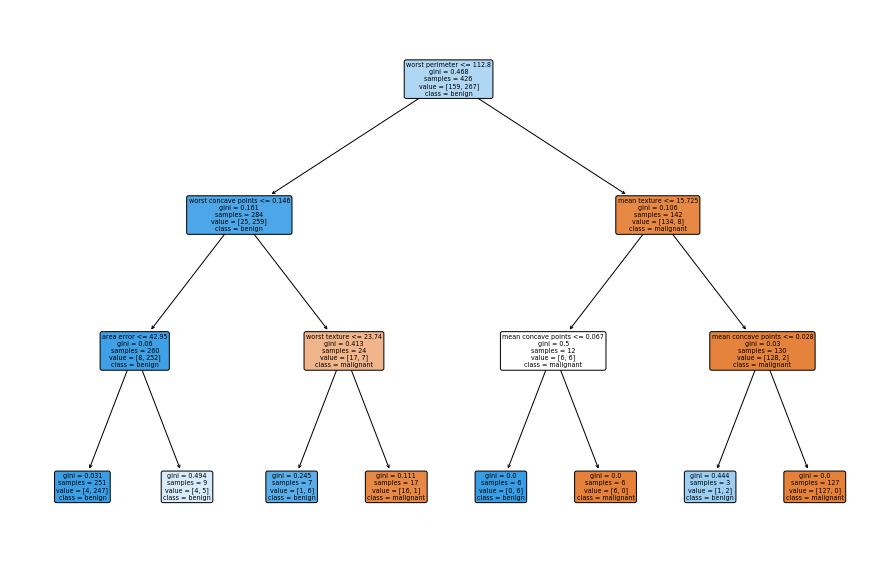

In [58]:
#결정트리 시각화
plt.figure(figsize=(15, 10))
plot_tree(dt, class_names=cancer.target_names, feature_names=cancer.feature_names, impurity=True, filled=True, rounded=True)
plt.show()

In [60]:
print(export_text(dt)) #텍스트 분기 확인

|--- feature_22 <= 112.80
|   |--- feature_27 <= 0.15
|   |   |--- feature_13 <= 42.95
|   |   |   |--- class: 1
|   |   |--- feature_13 >  42.95
|   |   |   |--- class: 1
|   |--- feature_27 >  0.15
|   |   |--- feature_21 <= 23.74
|   |   |   |--- class: 1
|   |   |--- feature_21 >  23.74
|   |   |   |--- class: 0
|--- feature_22 >  112.80
|   |--- feature_1 <= 15.72
|   |   |--- feature_7 <= 0.07
|   |   |   |--- class: 1
|   |   |--- feature_7 >  0.07
|   |   |   |--- class: 0
|   |--- feature_1 >  15.72
|   |   |--- feature_7 <= 0.03
|   |   |   |--- class: 1
|   |   |--- feature_7 >  0.03
|   |   |   |--- class: 0



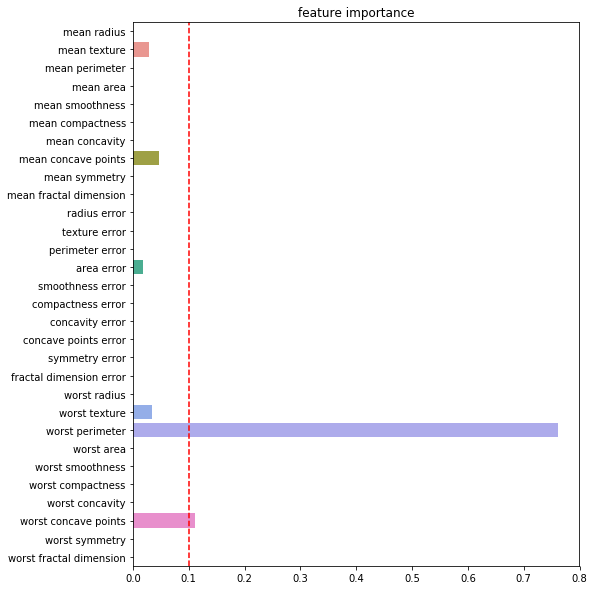

In [63]:
import seaborn as sns

#feature importance 확인
plt.figure(figsize=(8, 10))
fi = dt.feature_importances_
fn = cancer.feature_names
sns.barplot(fi, fn)
plt.title('feature importance')
plt.axvline(x=0.1, color='r', linestyle='--')
plt.show()

## 9-1-2. 앙상블

단일 모델보다 좋은 결과를 얻기 위해, 여러 모델을 결합한 모델  
최종 예측값을 얻기 위해 여러 모델(weak learner)의 예측값을 기반으로 voting을 진행한다.  
- hard voting: 각 모델들의 예측값을 바탕으로 다수결 투표 방식
- soft voting: 예측값들의 평균 또는 가중치 합을 사용하는 방식
- 스태킹: 모델의 예측값을 피처(입력값)로 지정하고, 실제값을 타겟으로 하여 새로운 모델을 생성 후 최종 예측값을 예측하는 방식

### 배깅(bootstrap aggregating)

중복을 허용한 랜덤 샘플링으로 원본과 동일한 크기의 여러 개의 훈련세트를 만들고 각각을 학습시킨 후 집계하는 방식  

샘플링은 일반적으로 원본데이터의 절반을 사용하는 방식인 subbagging을 사용하며, BaggingClassifier, BaggingRegressor의 max_samples로  
훈련세트의 크기를 지정할 수 있음
회귀분석을 할 시 이상치의 영향을 많이 받는 평균 대신 중위수를 사용하는 방식을 robust bagging이라고 함

- OOB: 랜덤샘플링이므로 데이터가 샘플에 한 번도 포함되지 않을 확률이 36.8%인데, 이러한 데이터를 OOB라고 함.  
  훈련에 사용되지 않은 데이터이므로 검증과 테스트에 사용할 수 있다. 
  - BaggingClassifier, BaggingRegressor의 oob_score = True → oob_score_로 검증

In [75]:
from sklearn.ensemble import BaggingClassifier

dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=4)
bagging = BaggingClassifier(dt, n_estimators=50, oob_score=True, random_state=0, max_samples=0.5, max_features=.5) #사용샘플수, 피처수
bagging.fit(train_X, train_Y)
pred = bagging.predict(test_X)
proba = bagging.predict_proba(test_X)[:, 1] #1에 대한 예측확률

#모델 학습결과
print(f"train set score: {bagging.score(train_X, train_Y):.3f}")
print(f"test set score: {bagging.score(test_X, test_Y):.3f}")
print(f"oob score: {bagging.oob_score_:.3f}")

#샘플수
print(f"첫번째 estimator bootstrap 샘플수: {len(bagging.estimators_samples_[0])}, 원본 샘플수: {len(train_X)}")
print(f"첫번째 estimator bootstrap 샘플수: {len(bagging.estimators_features_[0])}, 원본 샘플수: {train_X.shape[1]}")

train set score: 0.972
test set score: 0.958
oob score: 0.955
첫번째 estimator bootstrap 샘플수: 213, 원본 샘플수: 426
첫번째 estimator bootstrap 샘플수: 15, 원본 샘플수: 30


### 부스팅(boosting)

학습할 때마다 잔차가 큰 데이터 포인트들의 가중치를 높여가며 일련의 모델들을 생성하는 방법  
이전 모델이 갖는 오차를 줄이는 방향으로 다음 모델을 순차적으로 생성한다.  
주요 부스팅 알고리즘으로 Adaptive boosting, Gradient boosting, Stochastic gradient boosting이 있음

- Adaptive boosting(AdaBoost)  
  잔차에 따라 데이터의 가중치를 조절하는 부스팅의 초기버전, 앞서 생성한 모델의 예측결과와 실제 데이터의 차이가 클 수록 해당 데이터는  
  높은 가중치를 받게되며, 각 데이터마다 얻어진 가중치들은 그 다음 모델이 학습할 때 입력 값의 일부로 주어진다. 매 반복마다 가중치는  
  업데이트되며, 예측하기 어려운 데이터에 대해 더 집중해서 학습을 하도록 모델을 생성한다. 
  - AdaBoostClassifier, AdaBoostRegressor
  
- Gradient Boosting  
  전체 데이터의 오차를 최적화하는 접근법을 사용했다는 점에서 Adaboost와 차이가 있음. 가중치를 조정하는 대신 모델이 유사잔차를 학습  
  이 때, 잔차가 그레디언트로 표현되며 경사하강법을 사용하여 다음에 추가될 트리가 예측해야 할 값 보정
  - GradientBoostingRegressor, GradientBoostingClassifier: max_depth를 일반적으로 5 이하의 값 사용하며, learning_rate로 모델 복잡성제어
  
- Stochastic gradient boosting  
  학습할 때마다 데이터와 예측변수를 샘플링하는 방식으로 그래디언트 부스팅에 랜덤요소 추가  
  - XGBClassifier, XGBRegressor: subsampler(샘플링 입력데이터 비율 조정), eta(모델 복잡성) 조정 필요